🌟 Exercise 1: Duplicate Detection and Removal
Instructions
Objective: Identify and remove duplicate entries in the Titanic dataset.

Load the Titanic dataset.
Identify if there are any duplicate rows based on all columns.
Remove any duplicate rows found in the dataset.
Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.
Hint: Use the duplicated() and drop_duplicates() functions in Pandas.

In [5]:
import pandas as pd

df = pd.read_csv('/weatherdata.csv')

# Check the size
df = pd.read_csv('/weatherdata.csv', sep=';')
df.head()


,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,3379,19540601,-999,-999.0,-999.0,1,0.0,1,-999.0,0,-999.0,-999.0,-999.0,14.0,-999.0,17.6,10.4,-999.0,eor
1,3379,19540602,-999,-999.0,-999.0,1,0.5,1,-999.0,0,-999.0,-999.0,-999.0,13.2,-999.0,19.7,9.7,-999.0,eor
2,3379,19540603,-999,-999.0,-999.0,1,0.0,1,-999.0,0,-999.0,-999.0,-999.0,16.6,-999.0,21.9,8.2,-999.0,eor
3,3379,19540604,-999,-999.0,-999.0,1,1.2,1,-999.0,0,-999.0,-999.0,-999.0,15.2,-999.0,17.3,11.8,-999.0,eor
4,3379,19540605,-999,-999.0,-999.0,1,6.0,1,-999.0,0,-999.0,-999.0,-999.0,15.2,-999.0,17.7,13.7,-999.0,eor


In [6]:
# Check if there are dublicates
duplicates = df.duplicated()

In [7]:
# How many
duplicates.sum()

np.int64(0)

In [8]:
# Store the Size BEFORE
before = df.shape[0]

# Remove dublicates
df = df.drop_duplicates()

# Size AFTER
after = df.shape[0]

before, after

(25051, 25051)

In [9]:
df.duplicated().sum()

np.int64(0)

🌟 Exercise 2: Handling Missing Values
Instructions
Identify columns in the Titanic dataset with missing values.
Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
Apply each strategy to different columns based on the nature of the data.
Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.

In [15]:
# Check missing values
df = pd.read_csv('/train.csv')
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df = df.drop(columns=['Cabin'])

In [17]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [19]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


The dataset was analyzed for missing values using isnull().sum().

The Cabin column contained a large number of missing values and was removed.
The Age column had missing values and was filled using the median, as it is a numerical variable.
The Embarked column had only a few missing values and was filled with the most frequent value (mode).

These strategies allowed us to preserve as much data as possible while ensuring data quality.

🌟 Exercise 3: Feature Engineering
Instructions
Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.
Hint: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.

In [36]:
df = pd.read_csv('train.csv')

In [37]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [38]:
#title extraction
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df[['Name', 'Title']].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [39]:
#simplify title
df['Title'] = df['Title'].replace([
    'Lady', 'Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'
], 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


In [40]:
#encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,2,True,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,2,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,2,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,True,False,True,False,True,False,False


In [41]:
# Convert boolean columns to integers
df = df.astype(int, errors='ignore')

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,2,1,0,1,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,2,0,0,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,0,0,1,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,2,0,0,1,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,1,0,1,0,1,0,0


🌟 Exercise 4: Outlier Detection and Handling
Goal: Detect and cap or transform outliers in columns like Fare and Age.

1. Visualize distributions using boxplots or histograms to identify potential outliers.
2. Use IQR or Z-score methods to detect them.
3. Handle outliers with:

Quantile capping (e.g. 0.98)
Log transformation
Row removal
4. Compare the dataset before and after treatment.

📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.

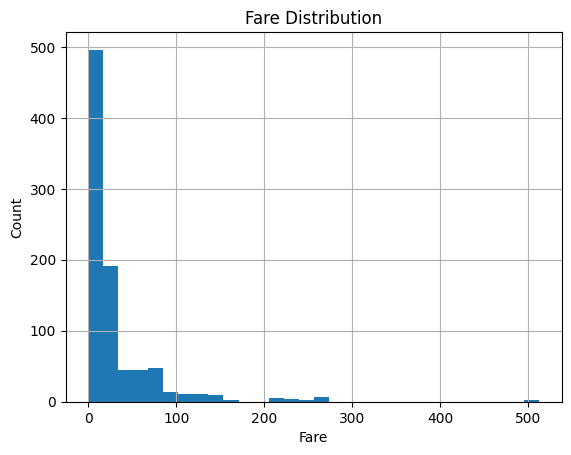

In [43]:
import matplotlib.pyplot as plt

# Histogram
df['Fare'].hist(bins=30)
# Visualizing Fare distribution to identify potential outliers
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

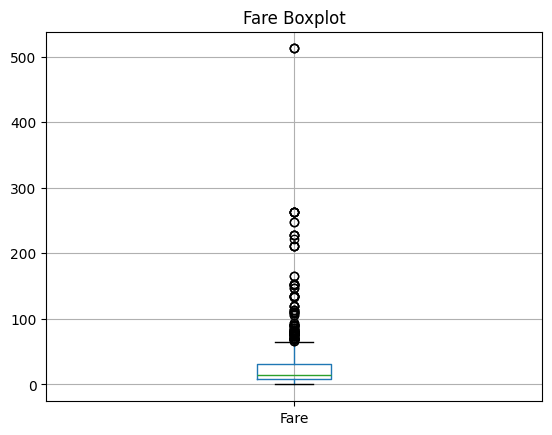

In [44]:
df.boxplot(column='Fare')
plt.title('Fare Boxplot')
plt.show()

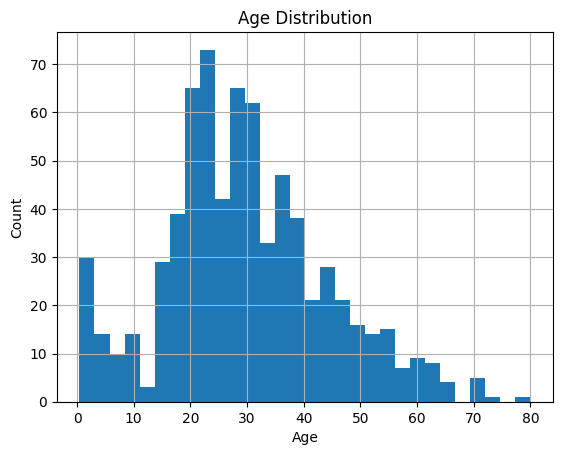

In [45]:
# Visualizing Age distribution
df['Age'].hist(bins=30)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

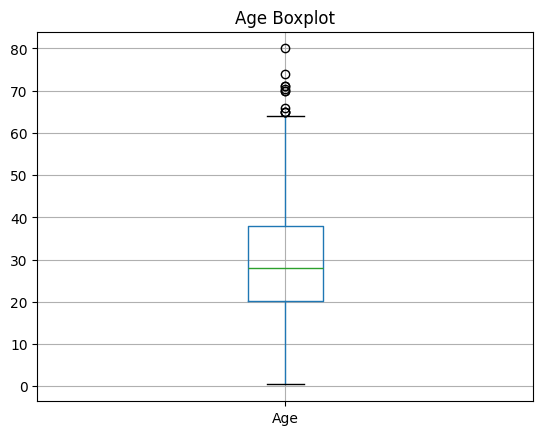

In [46]:
df.boxplot(column='Age')
plt.title('Age Boxplot')
plt.show()

In [48]:
# Calculate IQR for Fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-26.724), np.float64(65.6344))

In [49]:
df[df['Fare'] > upper_bound].shape

(116, 18)

In [52]:
# Cap Fare values at upper bound
df['Fare'] = df['Fare'].clip(upper=upper_bound)

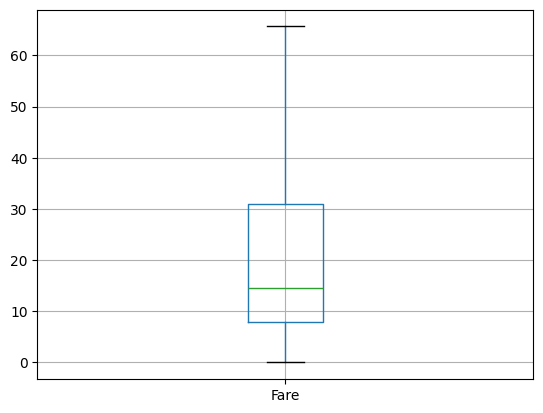

In [53]:
df.boxplot(column='Fare')
plt.show()

In [54]:
df['Fare'].describe()

,Fare
count,891.000000
mean,24.046813
std,20.481625
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,65.634400


# Comparing dataset before and after outlier treatment
# Before: Fare had extreme values up to ~512, causing high variance and skewness
# After: Values were capped at the upper bound (~65), reducing the impact of outliers
# This resulted in a more balanced distribution suitable for modeling

🌟 Exercise 5: Data Standardization and Normalization
Goal: Scale numerical features to prepare for modeling.

Use StandardScaler (mean = 0, std = 1) for normally distributed features.
Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
📌 Important: Perform this step after outlier treatment to avoid distortion caused by extreme values.

In [55]:
# Select numerical columns for scaling
num_cols = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']

df[num_cols].head()

,Age,Fare,FamilySize,SibSp,Parch
0,22.0,7.2500,2,1,0
1,38.0,65.6344,2,1,0
2,26.0,7.9250,1,0,0
3,35.0,53.1000,2,1,0
4,35.0,8.0500,1,0,0


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Age_scaled'] = scaler.fit_transform(df[['Age']])

In [57]:
df[['Age', 'Age_scaled']].head()

,Age,Age_scaled
0,22.0,-0.530377
1,38.0,0.571831
2,26.0,-0.254825
3,35.0,0.365167
4,35.0,0.365167


In [58]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Fare_scaled', 'FamilySize_scaled', 'SibSp_scaled', 'Parch_scaled']] = scaler.fit_transform(
    df[['Fare', 'FamilySize', 'SibSp', 'Parch']]
)

In [59]:
df[['Fare', 'Fare_scaled']].head()

,Fare,Fare_scaled
0,7.2500,0.110460
1,65.6344,1.000000
2,7.9250,0.120745
3,53.1000,0.809027
4,8.0500,0.122649


In [61]:
df[['FamilySize', 'FamilySize_scaled']].head()

,FamilySize,FamilySize_scaled
0,2,0.1
1,2,0.1
2,1,0.0
3,2,0.1
4,1,0.0


In [62]:
df[['SibSp', 'SibSp_scaled']].head()

,SibSp,SibSp_scaled
0,1,0.125
1,1,0.125
2,0,0.000
3,1,0.125
4,0,0.000


In [63]:
df[['Parch', 'Parch_scaled']].head()

,Parch,Parch_scaled
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0


# Data Standardization and Normalization

# StandardScaler was applied to the 'Age' column because it is approximately normally distributed.
# This transformation centers the data around 0 with a standard deviation of 1.

# MinMaxScaler was applied to 'Fare', 'FamilySize', 'SibSp', and 'Parch' because:
# - 'Fare' is highly skewed
# - The other features are discrete and have small ranges

# MinMax scaling transforms values into the range [0, 1], which helps models converge faster
# and ensures that all features are on a comparable scale.

🌟 Exercise 6: Feature Encoding
Goal: Finalize categorical variable encoding.

1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
2. Apply:

One-Hot Encoding for nominal variables.
Label Encoding if any ordinal variables remain.
3. Merge encoded columns back into the main dataset.

📌 Reminder: Encoding comes after handling missing values and outliers, but before scaling (if applicable).

In [64]:
# Check data types
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [65]:
df = df.drop(columns=['Name', 'Ticket'])

In [66]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Cabin,object
FamilySize,int64
Sex_male,int64


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        891 non-null    int64  
 1   Survived           891 non-null    int64  
 2   Pclass             891 non-null    int64  
 3   Age                714 non-null    float64
 4   SibSp              891 non-null    int64  
 5   Parch              891 non-null    int64  
 6   Fare               891 non-null    float64
 7   Cabin              204 non-null    object 
 8   FamilySize         891 non-null    int64  
 9   Sex_male           891 non-null    int64  
 10  Embarked_Q         891 non-null    int64  
 11  Embarked_S         891 non-null    int64  
 12  Title_Miss         891 non-null    int64  
 13  Title_Mr           891 non-null    int64  
 14  Title_Mrs          891 non-null    int64  
 15  Title_Rare         891 non-null    int64  
 16  Age_scaled         714 non

In [68]:
df = df.drop(columns=['Cabin'])

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        891 non-null    int64  
 1   Survived           891 non-null    int64  
 2   Pclass             891 non-null    int64  
 3   Age                714 non-null    float64
 4   SibSp              891 non-null    int64  
 5   Parch              891 non-null    int64  
 6   Fare               891 non-null    float64
 7   FamilySize         891 non-null    int64  
 8   Sex_male           891 non-null    int64  
 9   Embarked_Q         891 non-null    int64  
 10  Embarked_S         891 non-null    int64  
 11  Title_Miss         891 non-null    int64  
 12  Title_Mr           891 non-null    int64  
 13  Title_Mrs          891 non-null    int64  
 14  Title_Rare         891 non-null    int64  
 15  Age_scaled         714 non-null    float64
 16  Fare_scaled        891 non

🌟 Exercise 7: Data Transformation for Age Feature
Goal: Create and encode age groups.

Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
Apply one-hot encoding using pd.get_dummies().
📌 Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.


In [70]:
# Create age groups
bins = [0, 12, 18, 60, 100]
labels = ['child', 'teen', 'adult', 'senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [71]:
df[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,22.0,adult
1,38.0,adult
2,26.0,adult
3,35.0,adult
4,35.0,adult
5,NaN,NaN
6,54.0,adult
7,2.0,child
8,27.0,adult
9,14.0,teen


In [72]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
adult,553
teen,70
child,69
senior,22


In [73]:
df['AgeGroup'].isnull().sum()

np.int64(177)

In [74]:
df['AgeGroup'] = df['AgeGroup'].cat.add_categories('unknown')
df['AgeGroup'] = df['AgeGroup'].fillna('unknown')

In [75]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
adult,553
unknown,177
teen,70
child,69
senior,22


In [76]:
# drop_first=True removes one category to avoid multicollinearity
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

In [77]:
df.filter(like='AgeGroup').head()

,AgeGroup_teen,AgeGroup_adult,AgeGroup_senior,AgeGroup_unknown
0,False,True,False,False
1,False,True,False,False
2,False,True,False,False
3,False,True,False,False
4,False,True,False,False
